# Spatial-coupled LDPC 

In [2]:
import numpy as np

In [3]:
def generate_sc_ldpc_optimize(d_v=3, d_c=6, M=30, n_blk=20, coupling_width=3, seed=42):
    """
    Generate a spatial coupled LDPC matrix using socket matching and edge permutation.

    @param n_blk: number of variable blocks (total variable nodes = M * n_blk)
    @param M: number of variable nodes per block (lifting factor)
    @param d_v: degree of each variable node
    @param d_c: degree of each check node
    @param coupling_width: coupling window
    @param seed: random seed 

    @return: np.ndarray
    """
    if seed is not None: np.random.seed(seed)

    n_var = n_blk * M 
    n_check_per_blk = M * d_v // d_c
    n_check = (n_blk + coupling_width - 1) * n_check_per_blk
    H = np.zeros((n_check, n_var), dtype=int)

    # Prepare sockets for check nodes
    check_sockets = [list(np.repeat(np.arange(i * n_check_per_blk, (i+1) * n_check_per_blk), d_c))
                     for i in range(n_blk + coupling_width - 1)] 
    check_degs = [0] * n_check

    for blk in range(n_blk):

        var_sockets_per_blk = np.repeat(np.arange(blk * M, (blk+1) * M), d_v)
        # Prevent the scenario that mutiple edges in one check 
        # matched to the same variable nodes  
        np.random.shuffle(var_sockets_per_blk) 

        check_candidates = []
        if blk < coupling_width - 1:
            for w in range(coupling_width):
                check_candidates.extend(check_sockets[blk+w])
            np.random.shuffle(check_candidates)
            
        else: 
            # print("blk_id: ", blk)
            for w in range(coupling_width):
                check_blk = check_sockets[blk + w]
                np.random.shuffle(check_blk)
                check_candidates.extend(check_blk)
 
        assert len(check_candidates) >= len(var_sockets_per_blk), "Not enough check sockets to match variable sockets."
        edge_pairs = zip(check_candidates[:len(var_sockets_per_blk)], var_sockets_per_blk)
        used_pairs = set()
        
        for c, v in edge_pairs:
            while (c, v) in used_pairs or check_degs[c] >= d_c:
                c = np.random.choice(check_candidates)
            H[c, v] += 1
            used_pairs.add((c, v))
            check_degs[c] += 1
            assert H[c, v] <= 1

        # Remove connected check sockets
        for c, _ in used_pairs:
            blk_id = c // n_check_per_blk
            check_sockets[blk_id].remove(c)
    
    # print(check_degs)
    return H


In [4]:
import matplotlib.pyplot as plt

In [5]:
def bec_channel(x, erasure_prob=0.2):
    received = x.copy()
    erasures = np.random.rand(len(x)) < erasure_prob
    received[erasures] = -1  
    return received

In [6]:
def peeling_decoder(H, received):
    n_check, n_var = H.shape
    decoded = received.copy()
    assert len(received) == n_var, "Received length mismatch"
    
    while True:
        progress = False
        for i in range(n_check):
            idxs = np.where(H[i, :] == 1)[0]
            known = idxs[decoded[idxs] != -1]
            unknown = idxs[decoded[idxs] == -1]
            if len(unknown) == 1:
                j = unknown[0]
                parity = np.sum(decoded[known]) % 2
                decoded[j] = parity
                progress = True
        if not progress:
            break
    return decoded


In [7]:
import networkx as nx

In [8]:
def plot_tanner_graph(H, max_nodes=500):
    """
    Plot the Tanner graph of the LDPC matrix H.

    @param H: parity-check matrix (binary)
    @param max_nodes: max number of variable + check nodes to visualize
    """
    n_check, n_var = H.shape

    if n_var + n_check > max_nodes:
        print(f" Too large to plot ({n_var+n_check} nodes); showing only a slice.")
        H = H[:max_nodes//2, :max_nodes//2]
        n_check, n_var = H.shape

    G = nx.Graph()

    # Add variable nodes (prefix 'v') and check nodes (prefix 'c')
    G.add_nodes_from([f'v{i}' for i in range(n_var)], bipartite=0)
    G.add_nodes_from([f'c{i}' for i in range(n_check)], bipartite=1)

    # Add edges where H[i,j] == 1
    for c, v in zip(*np.where(H[:, :] == 1)):
        G.add_edge(f'c{c}', f'v{v}')

    # Position variable nodes on the left, check nodes on the right
    pos = {}
    pos.update({f'v{i}': (0, -i) for i in range(n_var)})
    pos.update({f'c{i}': (1, -i) for i in range(n_check)})

    plt.figure(figsize=(6, max(5, 0.3 * (n_var + n_check))))
    nx.draw(G, pos, node_size=20, with_labels=False, edge_color="gray")
    plt.title("Tanner Graph (variable nodes → check nodes)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


/var/folders/hj/8lltcq8x2tx946f07w9f9tkc0000gn/T/ipykernel_15938/1831245858.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


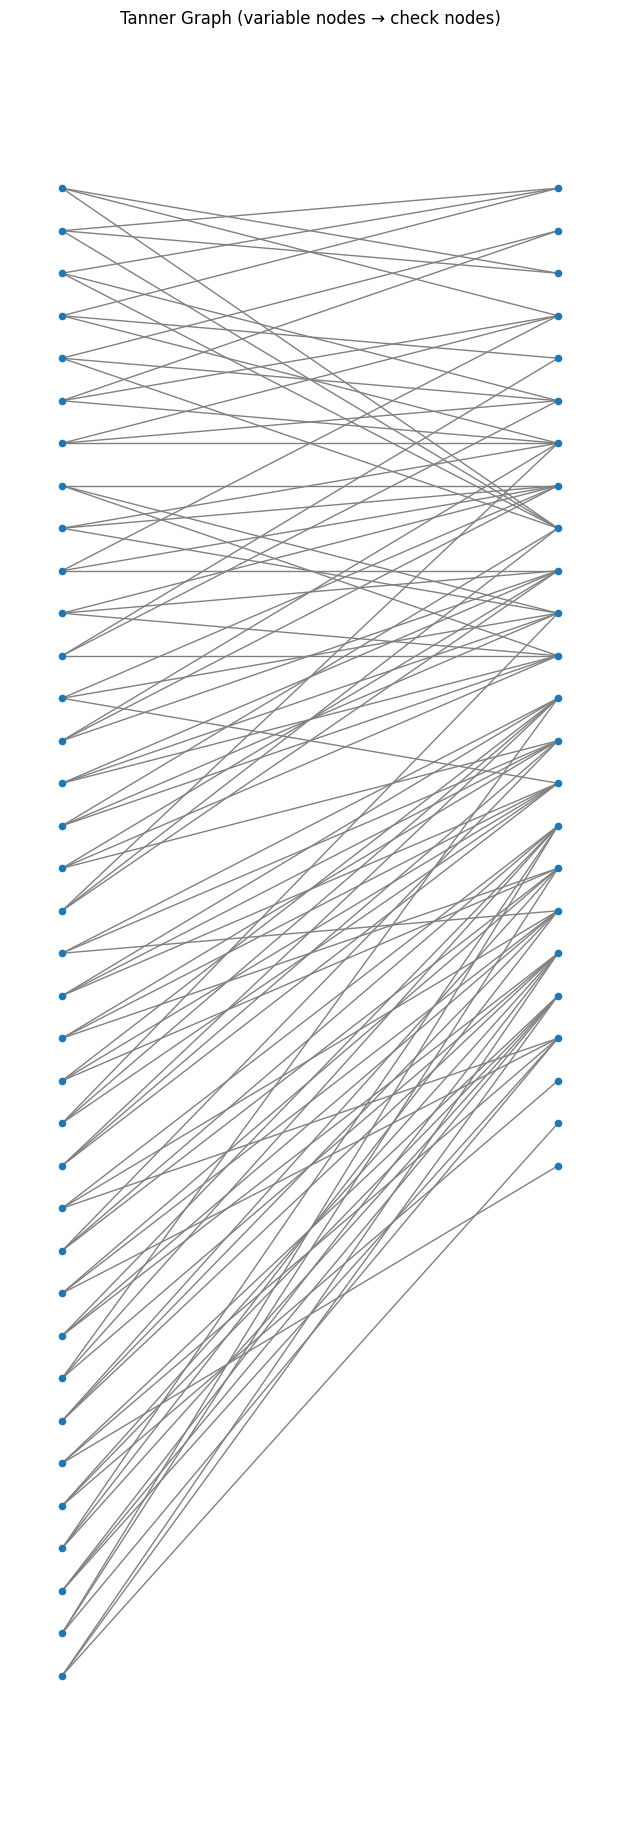

In [9]:
plot_tanner_graph(generate_sc_ldpc_optimize(3, 6, 6, 6))

In [11]:
def run_experiments(n, d_v, d_c, n_blk,
    coupling_width, start=0.06, end=0.09):
    num_trials = 200
    epsilons = np.linspace(start, end, 10)  

    success_rates = []

    np.random.seed(42)
    # H = generate_regular_ldpc(n_var=n, d_v=d_v, d_c=d_c)
    H = generate_sc_ldpc_optimize(d_v=d_v, d_c=d_c, M=n, n_blk=n_blk, coupling_width=coupling_width)
    print(f"variable degree: {d_v}, check degree: {d_c}, blk_size: {n}, blk_number: {n_blk}, coupling width: {coupling_width}")
    for eps in epsilons:
        success_count = 0
        for _ in range(num_trials):
            codeword = np.zeros(n * n_blk, dtype=int)  
            received = bec_channel(codeword, eps)
            decoded = peeling_decoder(H, received)
            if -1 not in decoded and np.all(np.mod(H @ decoded, 2) == 0):
                success_count += 1
        success_rate = success_count / num_trials
        success_rates.append(success_rate)
        print(f"Epsilon={eps:.3f}, Success Rate={success_rate:.3f}")

    plt.plot(epsilons, success_rates, marker='o')
    plt.xlabel('Erasure Probability (epsilon)')
    plt.ylabel('Success Rate')
    plt.title(f'(dv={d_v}, dc={d_c}) LDPC over BEC')
    plt.grid(True)
    plt.show()


variable degree: 4, check degree: 40, blk_size: 2000, blk_number: 50, coupling width: 5
Epsilon=0.060, Success Rate=0.995
Epsilon=0.063, Success Rate=0.990
Epsilon=0.067, Success Rate=0.985
Epsilon=0.070, Success Rate=0.990
Epsilon=0.073, Success Rate=1.000
Epsilon=0.077, Success Rate=0.965
Epsilon=0.080, Success Rate=0.605
Epsilon=0.083, Success Rate=0.100
Epsilon=0.087, Success Rate=0.000
Epsilon=0.090, Success Rate=0.000


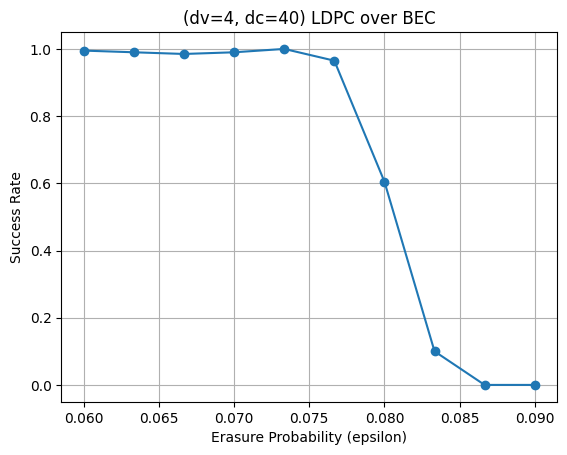

In [ ]:
run_experiments(2000, 4, 40, 50, 5)

In [ ]:
run_experiments(5000, 4, 40, 25, 5)

In [ ]:
run_experiments(5000, 4, 40, 50, 5)